# Logistic Regression

**Module 7: Categorical Outcomes** | Lean Six Sigma Data Analytics

---

## When to Use Logistic Regression

| Y Variable (CTQ) | X Variable (Influence Factor) | Method |
|------------------|-------------------------------|--------|
| Categorical | Numerical | **Logistic Regression** |

When you have a **categorical Y variable** and a **numerical X variable**, the suitable method is logistic regression.

---

## Steps of Logistic Regression

| Step | Action |
|------|--------|
| 1 | Convert data to event/trial format (if needed) |
| 2 | Make a fitted line plot and evaluate quality of fit |
| 3 | Analyze the p-value to check significance |

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for logistic regression analysis!')

Ready for logistic regression analysis!


---

## The Call Center Example

Suppose you work at a call center. When a customer calls, they get an automatic message that informs them of the estimated waiting time before a call center agent will be available.

**Question:** Will this influence whether a customer hangs up or not?

We measured two variables:

| Variable | Description | Type |
|----------|-------------|------|
| Hung up | Whether customer hung up (1) or not (0) | Categorical (binary) — **Y/CTQ** |
| Hold time | Announced waiting time in minutes | Numerical — **X/Influence factor** |

---

## Step 1: Event/Trial Format

The first step in logistic regression is to enter your data into an **event/trial format**.

| Column | Description |
|--------|-------------|
| Hold time | X variable values (waiting time in minutes) |
| Events (Hung up) | Number of times an event happened for that X value |
| Trials (Calls) | Total number of observations for that X value |

The original data might look like individual records (one row per customer). To convert to event/trial format, you group by the X variable and count events vs. trials.

In [2]:
# Load original data format
def load_callcenter_original():
    """Load original call center data: one row per customer"""
    df = pd.read_excel(xlsx, sheet_name='Callcenter', skiprows=11, header=0, usecols=[4, 5])
    df.columns = ['HoldTime', 'HungUp']
    return df.dropna().astype(int)

original_data = load_callcenter_original()
print('ORIGINAL DATA FORMAT')
print('=' * 50)
print('One row per customer:')
print(original_data.head(10))
print(f'\nTotal customers: {len(original_data)}')
print('\nHungUp: 1 = hung up, 0 = did not hang up')

ORIGINAL DATA FORMAT
One row per customer:
   HoldTime  HungUp
0        16       0
1        10       0
2        19       1
3        12       0
4        19       1
5         6       1
6        17       0
7        17       0
8         5       0
9         6       0

Total customers: 336

HungUp: 1 = hung up, 0 = did not hang up


In [3]:
# Convert to event/trial format using cross-tabulation
crosstab = pd.crosstab(original_data['HoldTime'], original_data['HungUp'])
event_trial = pd.DataFrame({
    'HoldTime': crosstab.index,
    'HungUp': crosstab[1].values,  # Events (hung up)
    'Calls': crosstab.sum(axis=1).values  # Total trials
})

print('CONVERSION TO EVENT/TRIAL FORMAT')
print('=' * 50)
print('\nUsing cross-tabulation to group by HoldTime:')
print(event_trial)
print(f'\nFor example, at HoldTime of 1 minute:')
print(f'  {event_trial.loc[0, "Calls"]} people had a 1 minute hold time')
print(f'  {event_trial.loc[0, "HungUp"]} person hung up')

CONVERSION TO EVENT/TRIAL FORMAT

Using cross-tabulation to group by HoldTime:
    HoldTime  HungUp  Calls
0          1       1     19
1          2       0     15
2          3       2     12
3          4       1     15
4          5       5     14
5          6       2     13
6          7       8     17
7          8      10     21
8          9       9     18
9         10       3     13
10        11       7     13
11        12      10     16
12        13       7     15
13        14       9     19
14        15      18     22
15        16      19     25
16        17      12     17
17        18      13     16
18        19      21     21
19        20      14     15

For example, at HoldTime of 1 minute:
  19 people had a 1 minute hold time
  1 person hung up


In [4]:
# Load pre-formatted event/trial data from file
def load_callcenter_event_trial():
    """Load call center data in event/trial format"""
    df = pd.read_excel(xlsx, sheet_name='Callcenter', skiprows=11, header=0, usecols=[0, 1, 2])
    df.columns = ['HoldTime', 'HungUp', 'Calls']
    return df.dropna().astype(int)

callcenter = load_callcenter_event_trial()
print('EVENT/TRIAL FORMAT (from data file)')
print('=' * 50)
print(callcenter)
print(f'\nHoldTime range: {callcenter["HoldTime"].min()} to {callcenter["HoldTime"].max()} minutes')

EVENT/TRIAL FORMAT (from data file)
    HoldTime  HungUp  Calls
0          1       1     19
1          2       0     15
2          3       2     12
3          4       1     15
4          5       5     14
5          6       2     13
6          7       8     17
7          8      10     21
8          9       9     18
9         10       3     13
10        11       7     13
11        12      10     16
12        13       7     15
13        14       9     19
14        15      18     22
15        16      19     25
16        17      12     17
17        18      13     16
18        19      21     21
19        20      14     15

HoldTime range: 1 to 20 minutes


---

## Step 2: Fitted Line Plot

Now we make a fitted line plot and evaluate the quality of the fit.

In [5]:
# Calculate observed proportions for plotting
callcenter['Proportion'] = callcenter['HungUp'] / callcenter['Calls']

# Fit logistic regression model using proportion with frequency weights
X = sm.add_constant(callcenter['HoldTime'])
model = sm.GLM(callcenter['Proportion'], X,
               family=sm.families.Binomial(),
               freq_weights=callcenter['Calls'])
results = model.fit()

print('LOGISTIC REGRESSION MODEL FITTED')
print('=' * 50)

LOGISTIC REGRESSION MODEL FITTED


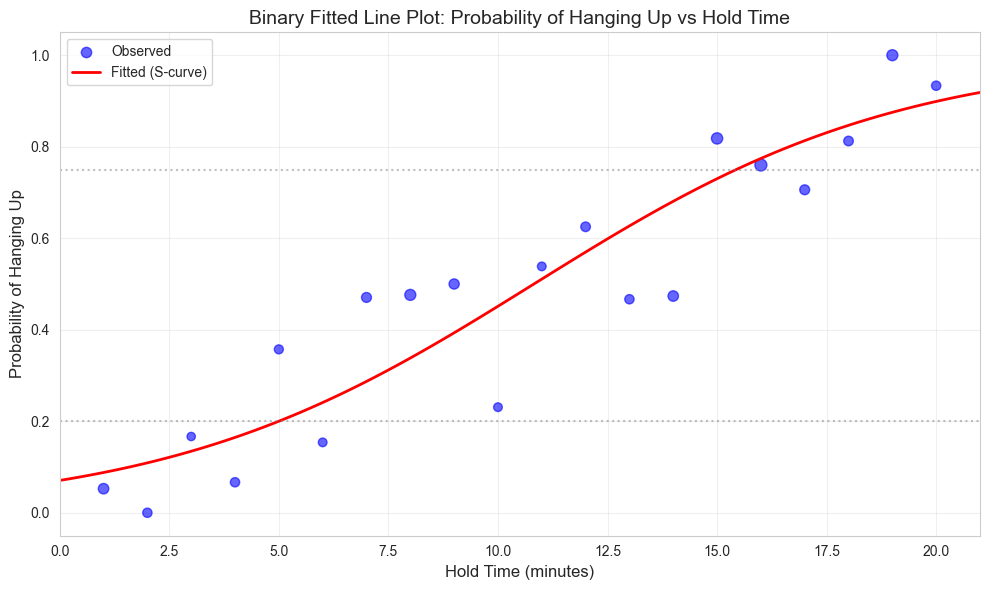

In [6]:
# Create fitted line plot (Binary Fitted Line Plot)
fig, ax = plt.subplots(figsize=(10, 6))

# Get model coefficients for prediction
intercept = results.params['const']
coef = results.params['HoldTime']

# Plot observed proportions (size proportional to number of calls)
ax.scatter(callcenter['HoldTime'], callcenter['Proportion'], 
           s=callcenter['Calls']*3, alpha=0.6, color='blue', label='Observed')

# Generate smooth prediction curve (S-curve) using logistic function
x_range = np.linspace(0, 21, 100)
y_pred = 1 / (1 + np.exp(-(intercept + coef * x_range)))

ax.plot(x_range, y_pred, color='red', linewidth=2, label='Fitted (S-curve)')

ax.set_xlabel('Hold Time (minutes)', fontsize=12)
ax.set_ylabel('Probability of Hanging Up', fontsize=12)
ax.set_title('Binary Fitted Line Plot: Probability of Hanging Up vs Hold Time', fontsize=14)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, 21)
ax.legend()
ax.grid(True, alpha=0.3)

# Add reference lines at key probabilities
ax.axhline(y=0.2, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=0.75, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
print('INTERPRETATION OF FITTED LINE PLOT')
print('=' * 50)
print()
print('The chance of hanging up INCREASES when the hold time increases.')
print()

# Predict at specific hold times using logistic function
intercept = results.params['const']
coef_holdtime = results.params['HoldTime']

for holdtime in [5, 15]:
    linear_pred = intercept + coef_holdtime * holdtime
    prob = 1 / (1 + np.exp(-linear_pred))
    print(f'At hold time of {holdtime} minutes:')
    print(f'  Probability of hanging up ≈ {prob:.2f} ({prob*100:.0f}%)')
    print()

print('Note: The fitted line is NOT straight but an S-shaped curve.')
print('This is because probability can never be below 0 or above 1.')

INTERPRETATION OF FITTED LINE PLOT

The chance of hanging up INCREASES when the hold time increases.

At hold time of 5 minutes:
  Probability of hanging up ≈ 0.20 (20%)

At hold time of 15 minutes:
  Probability of hanging up ≈ 0.73 (73%)

Note: The fitted line is NOT straight but an S-shaped curve.
This is because probability can never be below 0 or above 1.


---

## Step 3: Check Significance (P-Value)

Now we check if the results are significant — can they be generalized to the population?

In [8]:
print('LOGISTIC REGRESSION SUMMARY')
print('=' * 50)
print(results.summary())

LOGISTIC REGRESSION SUMMARY
                 Generalized Linear Model Regression Results                  
Dep. Variable:             Proportion   No. Observations:                   20
Model:                            GLM   Df Residuals:                      334
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -123.52
Date:                Sun, 21 Dec 2025   Deviance:                       28.848
Time:                        18:43:35   Pearson chi2:                     25.1
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9963
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5765   

In [9]:
# Extract key statistics
coef_holdtime = results.params['HoldTime']
pvalue_holdtime = results.pvalues['HoldTime']
intercept = results.params['const']

print('KEY RESULTS')
print('=' * 50)
print(f'\nIntercept (β₀): {intercept:.4f}')
print(f'HoldTime coefficient (β₁): {coef_holdtime:.4f}')
print(f'\nP-value for HoldTime: {pvalue_holdtime:.6f}')
print()

if pvalue_holdtime < 0.05:
    print('The p-value indicates that Hold Time is a SIGNIFICANT')
    print('influence factor on hanging up or not.')
else:
    print('The p-value indicates that Hold Time is NOT a significant')
    print('influence factor on hanging up or not.')

KEY RESULTS

Intercept (β₀): -2.5765
HoldTime coefficient (β₁): 0.2381

P-value for HoldTime: 0.000000

The p-value indicates that Hold Time is a SIGNIFICANT
influence factor on hanging up or not.


In [10]:
# Event summary
total_calls = callcenter['Calls'].sum()
total_hungup = callcenter['HungUp'].sum()
total_held = total_calls - total_hungup

print('EVENT SUMMARY')
print('=' * 50)
print(f'\nTotal calls: {total_calls}')
print(f'  Hung up: {total_hungup} ({total_hungup/total_calls*100:.1f}%)')
print(f'  Did not hang up: {total_held} ({total_held/total_calls*100:.1f}%)')

EVENT SUMMARY

Total calls: 336
  Hung up: 171 (50.9%)
  Did not hang up: 165 (49.1%)


---

## The Logistic Function

The formula for the S-shaped curve is not as simple as linear regression. It contains exponents which give it its S-shape:

$$P(\text{Event}) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}$$

Or equivalently:

$$P(\text{Event}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X)}}$$

Where $e$ is the exponential function (the $e^x$ or "A to the power X" button on your calculator).

In [11]:
print('LOGISTIC REGRESSION FORMULA')
print('=' * 50)
print(f'\nP(HungUp) = 1 / (1 + e^(-({intercept:.4f} + {coef_holdtime:.4f} × HoldTime)))')
print()
print('Example calculation for HoldTime = 10 minutes:')
linear_pred = intercept + coef_holdtime * 10
prob_10 = 1 / (1 + np.exp(-linear_pred))
print(f'  Linear predictor: {intercept:.4f} + {coef_holdtime:.4f} × 10 = {linear_pred:.4f}')
print(f'  P(HungUp) = 1 / (1 + e^(-{linear_pred:.4f})) = {prob_10:.4f}')

LOGISTIC REGRESSION FORMULA

P(HungUp) = 1 / (1 + e^(-(-2.5765 + 0.2381 × HoldTime)))

Example calculation for HoldTime = 10 minutes:
  Linear predictor: -2.5765 + 0.2381 × 10 = -0.1954
  P(HungUp) = 1 / (1 + e^(--0.1954)) = 0.4513


---

## Summary

**Logistic Regression** is used when you have:
- A **categorical Y** (CTQ) — typically binary (yes/no, 0/1)
- A **numerical X** (influence factor)

| Step | Action | Purpose |
|------|--------|--------|
| 1 | Organize data in event/trial format | Prepare data for analysis |
| 2 | Make a fitted line plot | Visualize relationship (S-curve) |
| 3 | Check if results are significant | Determine if findings can be generalized |

**Call Center Example Result:**
- P-value < 0.05 → Significant
- Hold time IS a significant influence factor on whether customers hang up
- Longer wait times increase the probability of hanging up